##Importar bibliotecas

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

##Dados

In [2]:
df = pd.read_excel('BaseCaseChurnPorto.xlsx')
df.head()

,CAT_ESTADO_CIVIL,CAT_GENERO,MESES_RELAC_PRODUTO,QTD_PRODUTOS_ATIVOS,IDADE,FLAG_CHURN
0,SOLTEIRO,M,186,2,37.0,0
1,NaN,NaN,66,1,NaN,0
2,CASADO,M,97,3,70.0,0
3,NaN,NaN,54,2,NaN,0
4,CASADO,M,4,1,63.0,0


###Análise dos dados

In [3]:
print("Informações do DataFrame:")
df.info()

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42803 entries, 0 to 42802
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CAT_ESTADO_CIVIL     24205 non-null  object 
 1   CAT_GENERO           25137 non-null  object 
 2   MESES_RELAC_PRODUTO  42803 non-null  int64  
 3   QTD_PRODUTOS_ATIVOS  42803 non-null  int64  
 4   IDADE                25137 non-null  float64
 5   FLAG_CHURN           42803 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 2.0+ MB


In [4]:
print("\nDados Faltantes por Coluna:")
df.isnull().sum()


Dados Faltantes por Coluna:


,0
CAT_ESTADO_CIVIL,18598
CAT_GENERO,17666
MESES_RELAC_PRODUTO,0
QTD_PRODUTOS_ATIVOS,0
IDADE,17666
FLAG_CHURN,0


In [5]:
df.describe()

,MESES_RELAC_PRODUTO,QTD_PRODUTOS_ATIVOS,IDADE,FLAG_CHURN
count,42803.000000,42803.000000,25137.000000,42803.000000
mean,47.141042,1.877462,50.998926,0.150690
std,52.219937,1.335101,14.386639,0.357751
min,1.000000,1.000000,19.000000,0.000000
25%,11.000000,1.000000,40.000000,0.000000
50%,29.000000,1.000000,51.000000,0.000000
75%,61.000000,3.000000,62.000000,0.000000
max,324.000000,15.000000,99.000000,1.000000


In [6]:
df['CAT_ESTADO_CIVIL'].value_counts()

,count
CAT_ESTADO_CIVIL,
CASADO,14236
SOLTEIRO,8342
VIUVO,823
DIVORCIADO,804


In [7]:
df['CAT_GENERO'].value_counts()

,count
CAT_GENERO,
M,14238
F,10868
I,27
N,4


In [8]:
df['FLAG_CHURN'].value_counts()

,count
FLAG_CHURN,
0,36353
1,6450


In [9]:
churn_rate = df['FLAG_CHURN'].mean()
print(f"\nTaxa geral de churn: {churn_rate:.2%}")


Taxa geral de churn: 15.07%


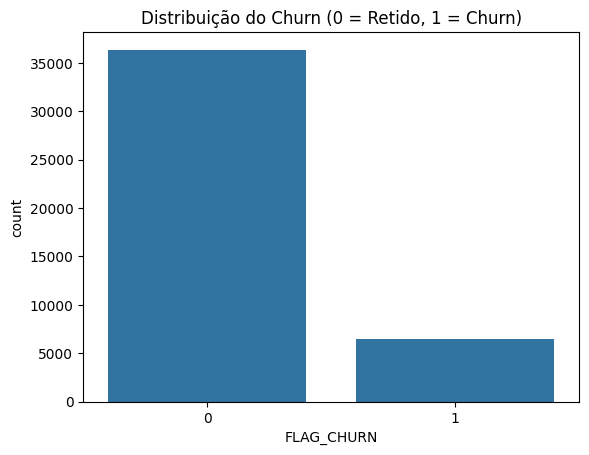

In [10]:
sns.countplot(data=df, x='FLAG_CHURN')
plt.title('Distribuição do Churn (0 = Retido, 1 = Churn)')
plt.show()

Text(0.5, 1.0, 'Churn por Estado Civil')

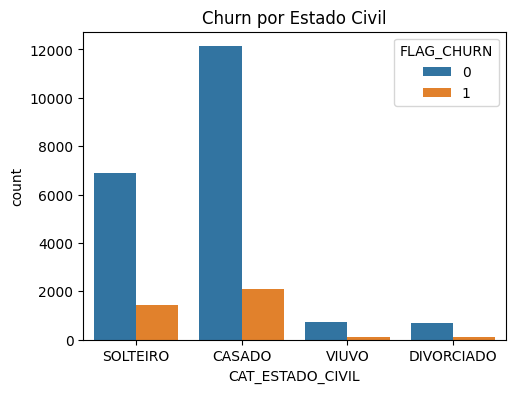

In [11]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='CAT_ESTADO_CIVIL', hue='FLAG_CHURN')
plt.title('Churn por Estado Civil')

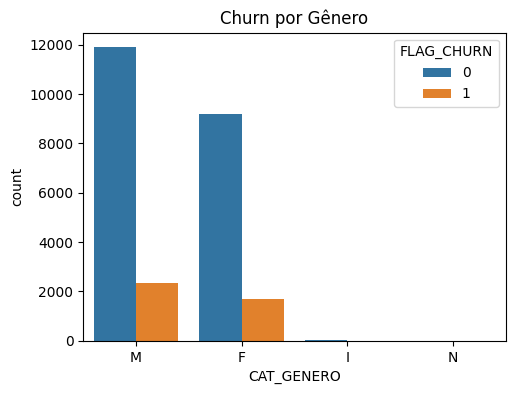

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='CAT_GENERO', hue='FLAG_CHURN')
plt.title('Churn por Gênero')
plt.show()

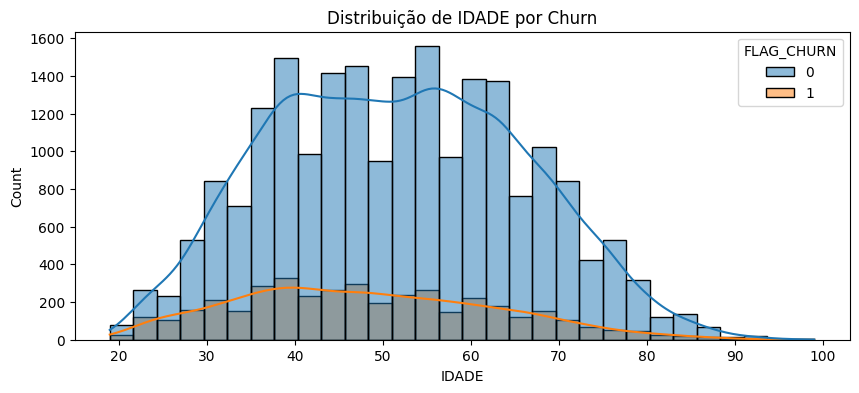

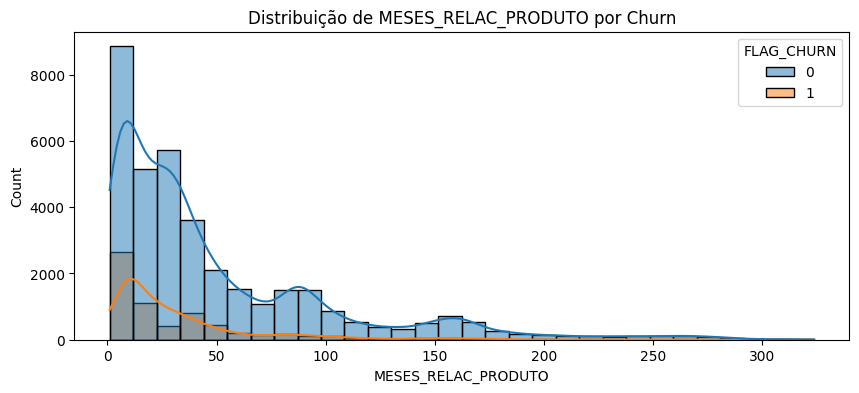

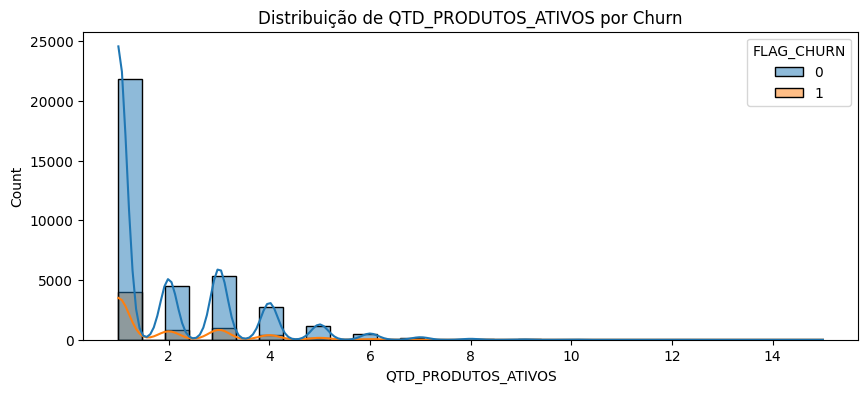

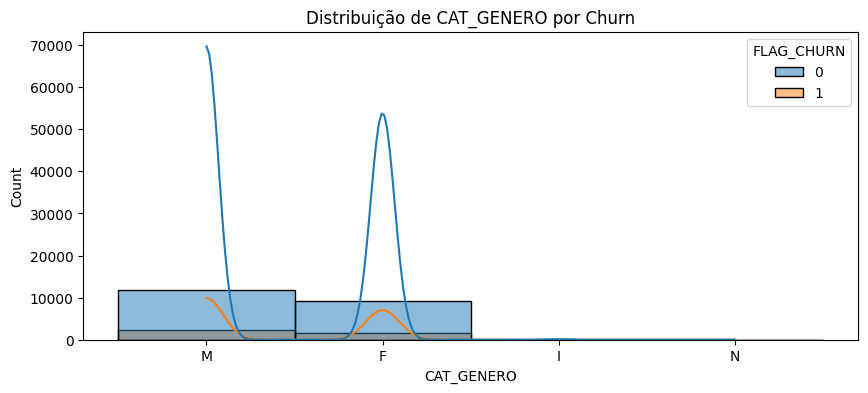

In [13]:
num_vars = ['IDADE', 'MESES_RELAC_PRODUTO', 'QTD_PRODUTOS_ATIVOS', 'CAT_GENERO']

for var in num_vars:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=df, x=var, hue='FLAG_CHURN', kde=True, bins=30)
    plt.title(f'Distribuição de {var} por Churn')
    plt.show()

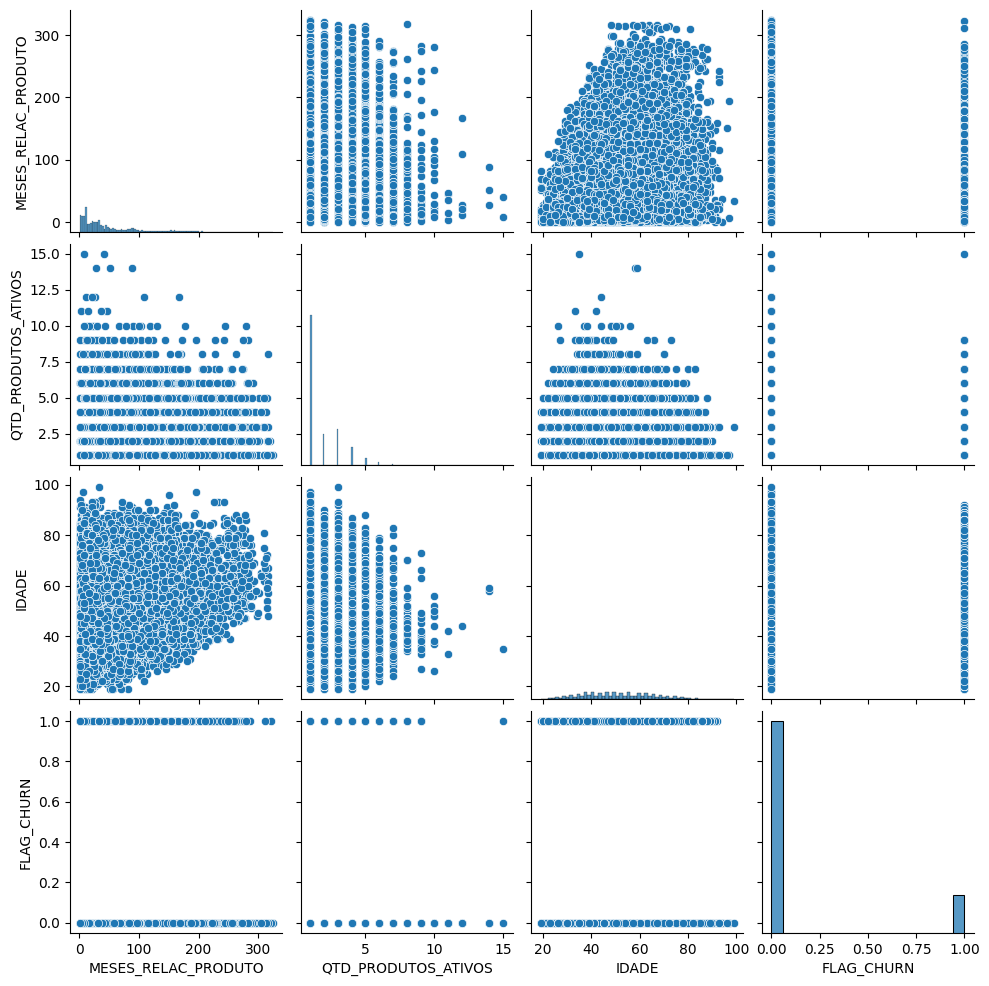

In [14]:
sns.pairplot(df)
plt.show()

##Correlações

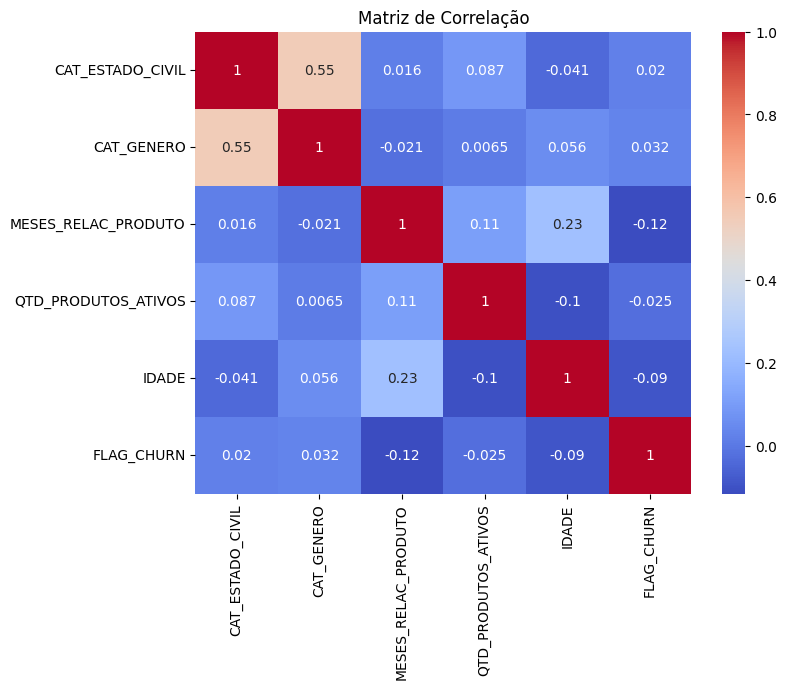

In [15]:
df_corr = df.copy()
df_corr['CAT_ESTADO_CIVIL'] = df_corr['CAT_ESTADO_CIVIL'].astype('category').cat.codes
df_corr['CAT_GENERO'] = df_corr['CAT_GENERO'].astype('category').cat.codes

corr_matrix = df_corr.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

###Preenchendo valores ausentes

In [16]:
df_model = df.copy()

###Pré-processamento

In [17]:
# Tratar valores nulos
cat_cols = ["CAT_ESTADO_CIVIL", "CAT_GENERO"]
num_cols = ["IDADE"]

cat_imputer = SimpleImputer(strategy="most_frequent")
num_imputer = SimpleImputer(strategy="mean")

df_model[cat_cols] = cat_imputer.fit_transform(df_model[cat_cols])
df_model[num_cols] = num_imputer.fit_transform(df_model[num_cols])

In [20]:
# Codificar variáveis categóricas
le_estado_civil = LabelEncoder()
le_genero = LabelEncoder()
df_model["CAT_ESTADO_CIVIL"] = le_estado_civil.fit_transform(df_model["CAT_ESTADO_CIVIL"])
df_model["CAT_GENERO"] = le_genero.fit_transform(df_model["CAT_GENERO"])

In [21]:
X = df_model.drop("FLAG_CHURN", axis=1)
y = df_model["FLAG_CHURN"]

In [22]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42803 entries, 0 to 42802
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CAT_ESTADO_CIVIL     42803 non-null  int64  
 1   CAT_GENERO           42803 non-null  int64  
 2   MESES_RELAC_PRODUTO  42803 non-null  int64  
 3   QTD_PRODUTOS_ATIVOS  42803 non-null  int64  
 4   IDADE                42803 non-null  float64
 5   FLAG_CHURN           42803 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 2.0 MB


In [23]:
df_model.drop_duplicates(inplace=True)

In [24]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21599 entries, 0 to 42802
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CAT_ESTADO_CIVIL     21599 non-null  int64  
 1   CAT_GENERO           21599 non-null  int64  
 2   MESES_RELAC_PRODUTO  21599 non-null  int64  
 3   QTD_PRODUTOS_ATIVOS  21599 non-null  int64  
 4   IDADE                21599 non-null  float64
 5   FLAG_CHURN           21599 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 1.2 MB


### Divisão em treino e teste


In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

           0       0.91      0.95      0.93      7230
           1       0.63      0.51      0.56      1331

    accuracy                           0.88      8561
   macro avg       0.77      0.73      0.75      8561
weighted avg       0.87      0.88      0.87      8561



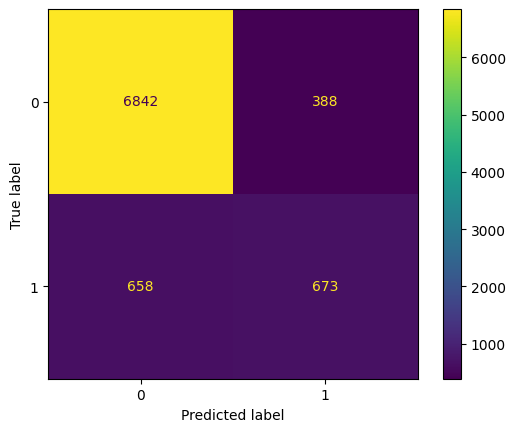

In [29]:
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.show()

In [31]:
from xgboost import XGBClassifier

XGB = XGBClassifier(random_state=42, max_depth=10)
XGB.fit(X_train_scaled, y_train)

y_pred_XGB = XGB.predict(X_test_scaled)
print(classification_report(y_test, y_pred_XGB, digits=4))

              precision    recall  f1-score   support

           0     0.9181    0.9488    0.9332      7230
           1     0.6602    0.5402    0.5942      1331

    accuracy                         0.8853      8561
   macro avg     0.7892    0.7445    0.7637      8561
weighted avg     0.8780    0.8853    0.8805      8561



In [32]:
from lightgbm import LGBMClassifier

LGBM = LGBMClassifier(random_state=42, max_depth=10,
                      verbose=-1)
LGBM.fit(X_train_scaled, y_train)

y_pred_LGBM = LGBM.predict(X_test_scaled)
print(classification_report(y_test, y_pred_LGBM, digits=4))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


              precision    recall  f1-score   support

           0     0.9234    0.9556    0.9392      7230
           1     0.7025    0.5695    0.6290      1331

    accuracy                         0.8956      8561
   macro avg     0.8130    0.7625    0.7841      8561
weighted avg     0.8891    0.8956    0.8910      8561



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Distribuição das classes após oversampling:
FLAG_CHURN
0    29123
1    29123
Name: count, dtype: int64

Relatório de Classificação após oversampling:
              precision    recall  f1-score   support

           0       0.93      0.90      0.91      7230
           1       0.52      0.62      0.57      1331

    accuracy                           0.85      8561
   macro avg       0.73      0.76      0.74      8561
weighted avg       0.86      0.85      0.86      8561



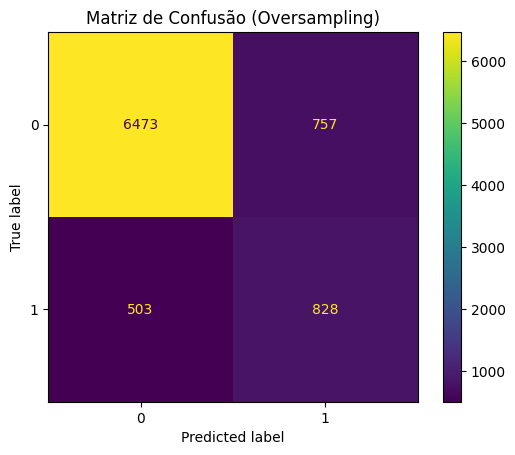

In [30]:
from imblearn.over_sampling import RandomOverSampler

# Instanciar o RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Aplicar o oversampling aos dados de treino
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Verificar a distribuição das classes nos dados reamostrados
print("Distribuição das classes após oversampling:")
print(pd.Series(y_train_resampled).value_counts())

# Treinar o modelo Random Forest novamente com os dados reamostrados
model_resampled = RandomForestClassifier(random_state=42)
model_resampled.fit(X_train_resampled, y_train_resampled)

# Avaliação do modelo treinado com oversampling
y_pred_resampled = model_resampled.predict(X_test)

print("\nRelatório de Classificação após oversampling:")
print(classification_report(y_test, y_pred_resampled))

# Matriz de Confusão para o modelo treinado com oversampling
cm_resampled = confusion_matrix(y_test, y_pred_resampled, labels=model_resampled.classes_)
disp_resampled = ConfusionMatrixDisplay(confusion_matrix=cm_resampled, display_labels=model_resampled.classes_)
disp_resampled.plot()
plt.title('Matriz de Confusão (Oversampling)')
plt.show()

Distribuição das classes após oversampling:
FLAG_CHURN
0    29123
1    29123
Name: count, dtype: int64

Relatório de Classificação após oversampling:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7230
           1       0.52      0.76      0.62      1331

    accuracy                           0.85      8561
   macro avg       0.74      0.82      0.76      8561
weighted avg       0.88      0.85      0.86      8561



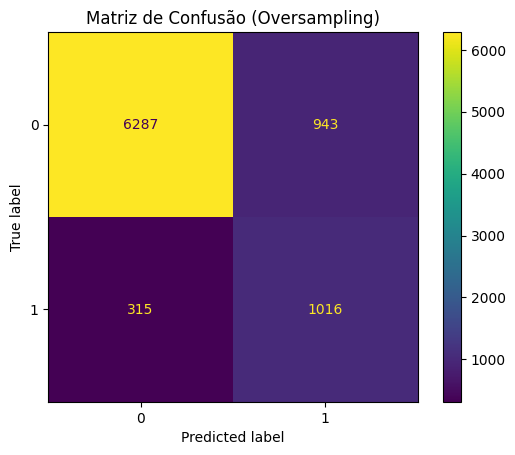

In [37]:
# Instanciar o RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Aplicar o oversampling aos dados de treino
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

# Verificar a distribuição das classes nos dados reamostrados
print("Distribuição das classes após oversampling:")
print(pd.Series(y_train_resampled).value_counts())

# Treinar o modelo Random Forest novamente com os dados reamostrados
model_resampled = LGBMClassifier(random_state=42)
model_resampled.fit(X_train_resampled, y_train_resampled)

# Avaliação do modelo treinado com oversampling
y_pred_resampled = model_resampled.predict(X_test)

print("\nRelatório de Classificação após oversampling:")
print(classification_report(y_test, y_pred_resampled))

# Matriz de Confusão para o modelo treinado com oversampling
cm_resampled = confusion_matrix(y_test, y_pred_resampled, labels=model_resampled.classes_)
disp_resampled = ConfusionMatrixDisplay(confusion_matrix=cm_resampled, display_labels=model_resampled.classes_)
disp_resampled.plot()
plt.title('Matriz de Confusão (Oversampling)')
plt.show()

Distribuição das classes após oversampling:
FLAG_CHURN
0    29123
1    29123
Name: count, dtype: int64


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Relatório de Classificação após oversampling:
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      7230
           1       0.52      0.76      0.62      1331

    accuracy                           0.85      8561
   macro avg       0.74      0.82      0.76      8561
weighted avg       0.88      0.85      0.86      8561



/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


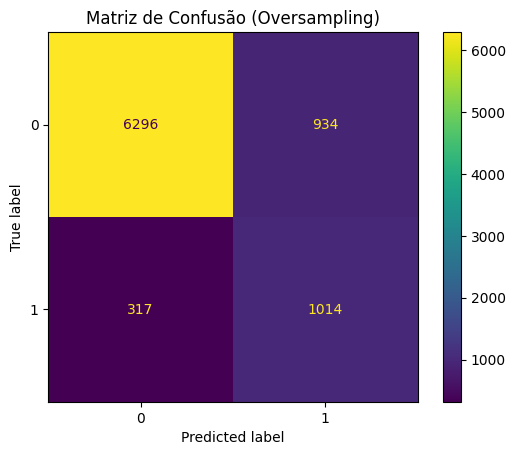

In [41]:
X_train_scaled_resampled = scaler.fit_transform(X_train)


# Instanciar o RandomOverSampler
ros = RandomOverSampler(random_state=42)

# Aplicar o oversampling aos dados de treino
X_train_resampled, y_train_resampled = ros.fit_resample(X_train_scaled, y_train)
X_train_scaled_resampled = scaler.fit_transform(X_train)

# Verificar a distribuição das classes nos dados reamostrados
print("Distribuição das classes após oversampling:")
print(pd.Series(y_train_resampled).value_counts())

# Treinar o modelo Random Forest novamente com os dados reamostrados
model_resampled = LGBMClassifier(random_state=42)
model_resampled.fit(X_train_resampled, y_train_resampled)

# Avaliação do modelo treinado com oversampling
y_pred_resampled = model_resampled.predict(X_test_scaled)

print("\nRelatório de Classificação após oversampling:")
print(classification_report(y_test, y_pred_resampled))

# Matriz de Confusão para o modelo treinado com oversampling
cm_resampled = confusion_matrix(y_test, y_pred_resampled, labels=model_resampled.classes_)
disp_resampled = ConfusionMatrixDisplay(confusion_matrix=cm_resampled, display_labels=model_resampled.classes_)
disp_resampled.plot()
plt.title('Matriz de Confusão (Oversampling)')
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(



Relatório de Classificação com pesos ajustados para a classe 0:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93      7230
           1       0.59      0.70      0.64      1331

    accuracy                           0.88      8561
   macro avg       0.77      0.80      0.78      8561
weighted avg       0.89      0.88      0.88      8561



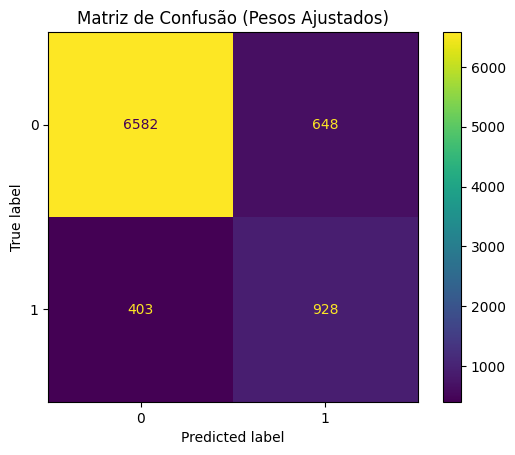

In [40]:
# Calcular os pesos das classes manualmente
class_weights = {0: 1, 1: 3}  # Aumentando o peso para a classe 0

# Treinar modelo Random Forest com pesos de classe definidos manualmente
model_weighted = LGBMClassifier(random_state=42, class_weight=class_weights)
model_weighted.fit(X_train_scaled, y_train)

# Avaliação do modelo com pesos ajustados
y_pred_weighted = model_weighted.predict(X_test_scaled)

print("\nRelatório de Classificação com pesos ajustados para a classe 0:")
print(classification_report(y_test, y_pred_weighted))

# Matriz de Confusão para o modelo com pesos ajustados
cm_weighted = confusion_matrix(y_test, y_pred_weighted, labels=model_weighted.classes_)
disp_weighted = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=model_weighted.classes_)
disp_weighted.plot()
plt.title('Matriz de Confusão (Pesos Ajustados)')
plt.show()